# Feature Engineering

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
sns.set_style('whitegrid')
import os 
import glob
import warnings
warnings.filterwarnings('ignore')

### Data Ingestion

In [2]:
file_path = r"F:\Data Science Projects\Bank_Telemarketing\Bank_Telemarketing\data\processed\bank_train_res.csv"

In [3]:
df = pd.read_csv(file_path)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,31,technician,married,high.school,no,yes,yes,cellular,nov,thu,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,no
1,23,admin.,married,high.school,no,yes,no,cellular,jul,tue,...,1,999,2,failure,-1.7,94.215,-40.3,0.797,4991.6,yes
2,32,services,single,basic.6y,no,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,no
3,38,technician,single,professional.course,no,yes,no,cellular,aug,tue,...,4,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,no
4,32,technician,single,professional.course,no,yes,no,cellular,may,wed,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.334,5099.1,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56160 entries, 0 to 56159
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             56160 non-null  int64  
 1   job             56160 non-null  object 
 2   marital         56160 non-null  object 
 3   education       56160 non-null  object 
 4   default         56160 non-null  object 
 5   housing         56160 non-null  object 
 6   loan            56160 non-null  object 
 7   contact         56160 non-null  object 
 8   month           56160 non-null  object 
 9   day_of_week     56160 non-null  object 
 10  duration        56160 non-null  int64  
 11  campaign        56160 non-null  int64  
 12  pdays           56160 non-null  int64  
 13  previous        56160 non-null  int64  
 14  poutcome        56160 non-null  object 
 15  emp.var.rate    56160 non-null  float64
 16  cons.price.idx  56160 non-null  float64
 17  cons.conf.idx   56160 non-null 

### Data Wrangling

In [5]:
mask_cat = lambda x: df[x].dtype == 'O'
cat_cols = list(filter(mask_cat,df.columns))
cat_cols.remove('y')
print('Categorical Features: ',cat_cols)

Categorical Features:  ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [6]:
mask_num = lambda x: df[x].dtype != 'O'
num_cols = list(filter(mask_num,df.columns))
print('Numerical Features: ',num_cols)

Numerical Features:  ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [7]:
df_num = df.drop(cat_cols,axis=1)
df_num['y'] = df_num['y'].map(dict(yes=1,no=0))
df_num.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,31,435,1,999,0,-0.1,93.200,-42.0,4.076,5195.8,0
1,23,210,1,999,2,-1.7,94.215,-40.3,0.797,4991.6,1
2,32,112,1,999,0,1.1,93.994,-36.4,4.858,5191.0,0
3,38,99,4,999,0,1.4,93.444,-36.1,4.963,5228.1,0
4,32,97,2,999,0,-1.8,92.893,-46.2,1.334,5099.1,0


In [8]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

scaler = MinMaxScaler()
num_scl = scaler.fit_transform(df_num)
df_num_scl = pd.DataFrame(num_scl,columns=df_num.columns) 
df_num_scl.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,0.172840,0.675466,0.000000,1.0,0.000000,0.687500,0.389322,0.368201,0.780322,0.877883,0.0
1,0.074074,0.326087,0.000000,1.0,0.285714,0.354167,0.784879,0.439331,0.036953,0.105860,1.0
2,0.185185,0.173913,0.000000,1.0,0.000000,0.937500,0.698753,0.602510,0.957606,0.859735,0.0
3,0.259259,0.153727,0.054545,1.0,0.000000,1.000000,0.484412,0.615063,0.981410,1.000000,0.0
4,0.185185,0.150621,0.018182,1.0,0.000000,0.333333,0.269680,0.192469,0.158694,0.512287,0.0


In [9]:
df_cat = df.drop(num_cols,axis=1)
df_cat.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,technician,married,high.school,no,yes,yes,cellular,nov,thu,nonexistent,no
1,admin.,married,high.school,no,yes,no,cellular,jul,tue,failure,yes
2,services,single,basic.6y,no,yes,yes,telephone,may,mon,nonexistent,no
3,technician,single,professional.course,no,yes,no,cellular,aug,tue,nonexistent,no
4,technician,single,professional.course,no,yes,no,cellular,may,wed,nonexistent,no


In [10]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
cat_enc = encoder.fit_transform(df_cat)
df_cat_enc = pd.DataFrame(cat_enc,columns=df_cat.columns)
df_cat_enc.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,9.0,1.0,3.0,0.0,1.0,1.0,0.0,7.0,2.0,1.0,0.0
1,0.0,1.0,3.0,0.0,1.0,0.0,0.0,3.0,3.0,0.0,1.0
2,7.0,2.0,1.0,0.0,1.0,1.0,1.0,6.0,1.0,1.0,0.0
3,9.0,2.0,5.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,0.0
4,9.0,2.0,5.0,0.0,1.0,0.0,0.0,6.0,4.0,1.0,0.0


In [11]:
df_int = pd.concat([df_cat_enc.drop('y',axis=1),df_num_scl],axis=1)
df_int.reset_index(inplace=True,drop=True)
df_int.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,...,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,9.0,1.0,3.0,0.0,1.0,1.0,0.0,7.0,2.0,1.0,...,0.675466,0.000000,1.0,0.000000,0.687500,0.389322,0.368201,0.780322,0.877883,0.0
1,0.0,1.0,3.0,0.0,1.0,0.0,0.0,3.0,3.0,0.0,...,0.326087,0.000000,1.0,0.285714,0.354167,0.784879,0.439331,0.036953,0.105860,1.0
2,7.0,2.0,1.0,0.0,1.0,1.0,1.0,6.0,1.0,1.0,...,0.173913,0.000000,1.0,0.000000,0.937500,0.698753,0.602510,0.957606,0.859735,0.0
3,9.0,2.0,5.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,...,0.153727,0.054545,1.0,0.000000,1.000000,0.484412,0.615063,0.981410,1.000000,0.0
4,9.0,2.0,5.0,0.0,1.0,0.0,0.0,6.0,4.0,1.0,...,0.150621,0.018182,1.0,0.000000,0.333333,0.269680,0.192469,0.158694,0.512287,0.0


### Correlation Studies

Chi-Squared Test

In [12]:
from scipy.stats import chi2_contingency
from itertools import product

cat_var1 = df_cat.columns.to_list()
cat_var2 = df_cat.columns.to_list()

cat_var_prod = list(product(cat_var1,cat_var2,repeat=1))

results = []

for i in cat_var_prod:
    results.append((i[0],i[1],list(chi2_contingency(pd.crosstab(df_cat[i[0]],df_cat[i[1]])))[1]))
    
chi_test_output = pd.DataFrame(results,columns=['var1','var2','pvalue'])
chi_test_pivot = chi_test_output.pivot(index='var1',columns='var2',values='pvalue')
chi_test_pivot

var2,contact,day_of_week,default,education,housing,job,loan,marital,month,poutcome,y
var1,,,,,,,,,,,
contact,0.000000e+00,7.744915e-53,1.000000,0.000000e+00,2.260337e-54,0.000000e+00,1.066962e-87,6.111019e-78,0.000000e+00,0.000000e+00,0.000000e+00
day_of_week,7.744915e-53,0.000000e+00,0.082266,3.340015e-26,4.425482e-15,6.303296e-99,3.225822e-06,9.400084e-19,0.000000e+00,1.432953e-22,2.638907e-74
default,1.000000e+00,8.226621e-02,0.000000,8.913303e-03,1.000000e+00,2.746718e-01,1.000000e+00,5.568406e-01,3.148856e-01,7.127753e-01,4.794923e-01
education,0.000000e+00,3.340015e-26,0.008913,0.000000e+00,1.424831e-17,0.000000e+00,4.578894e-35,0.000000e+00,0.000000e+00,7.311805e-201,0.000000e+00
housing,2.260337e-54,4.425482e-15,1.000000,1.424831e-17,0.000000e+00,5.156633e-09,2.367708e-30,2.379221e-04,1.057631e-127,6.659481e-07,2.594141e-14
job,0.000000e+00,6.303296e-99,0.274672,0.000000e+00,5.156633e-09,0.000000e+00,3.126690e-106,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
loan,1.066962e-87,3.225822e-06,1.000000,4.578894e-35,2.367708e-30,3.126690e-106,0.000000e+00,4.987571e-07,1.032029e-137,1.410595e-105,0.000000e+00
marital,6.111019e-78,9.400084e-19,0.556841,0.000000e+00,2.379221e-04,0.000000e+00,4.987571e-07,0.000000e+00,1.182035e-235,4.370437e-12,1.475959e-110
month,0.000000e+00,0.000000e+00,0.314886,0.000000e+00,1.057631e-127,0.000000e+00,1.032029e-137,1.182035e-235,0.000000e+00,0.000000e+00,0.000000e+00


In [13]:
print('Testing the Statistical Significance of features based on pvalue considering a Confidence Interval of 95%')
mask = chi_test_pivot['y'] <= 0.05
print('Statistically Significant Features: ',mask[mask == True].index.to_list())
print('Statistically Insignificant Features: ',mask[mask == False].index.to_list())

Testing the Statistical Significance of features based on pvalue considering a Confidence Interval of 95%
Statistically Significant Features:  ['contact', 'day_of_week', 'education', 'housing', 'job', 'loan', 'marital', 'month', 'poutcome', 'y']
Statistically Insignificant Features:  ['default']


In [14]:
chi_test_pivot['y'].sort_values()

var1
contact         0.000000e+00
education       0.000000e+00
job             0.000000e+00
loan            0.000000e+00
month           0.000000e+00
poutcome        0.000000e+00
y               0.000000e+00
marital        1.475959e-110
day_of_week     2.638907e-74
housing         2.594141e-14
default         4.794923e-01
Name: y, dtype: float64

Cramer's V [Symmetric: U(x,y) = U(y,x)]

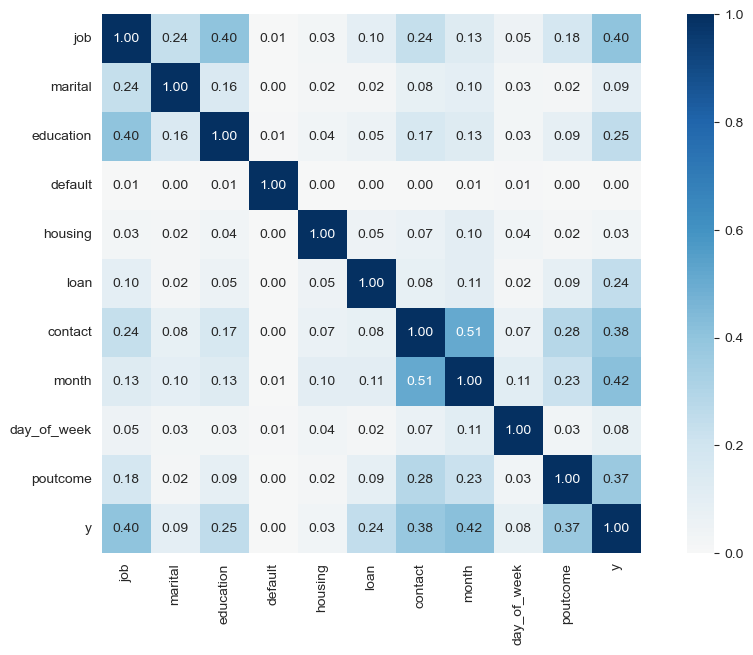

In [15]:
from dython.nominal import associations

fig,ax = plt.subplots(figsize=(12,7))
cramers_v = associations(df_cat,nom_nom_assoc='cramer',ax=ax,cmap='RdBu',vmin=0,vmax=1)

Theil's U [Asymmetric: U(x,y) != U(y,x)]

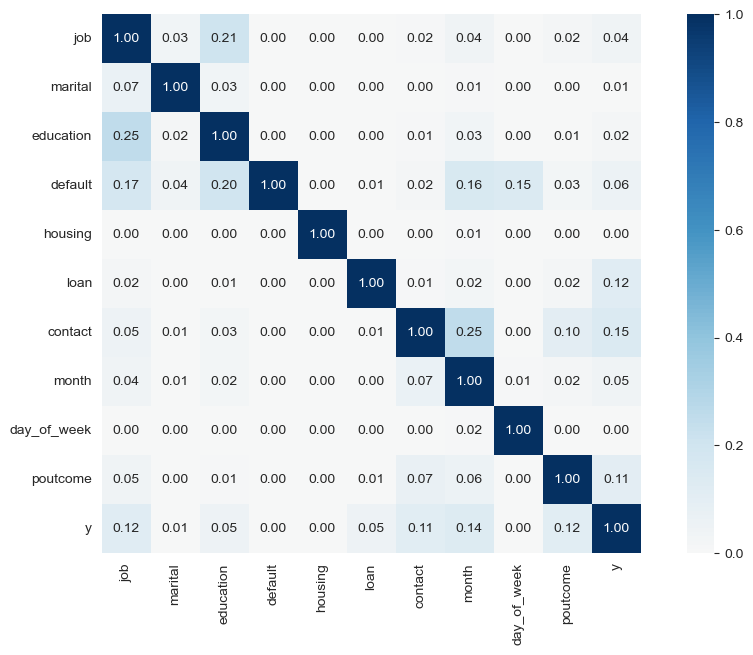

In [16]:
fig,ax = plt.subplots(figsize=(12,7))
theils_u = associations(df_cat,nom_nom_assoc='theil',ax=ax,cmap='RdBu',vmin=0,vmax=1)

Pearson Correlation (Linear Relationships)

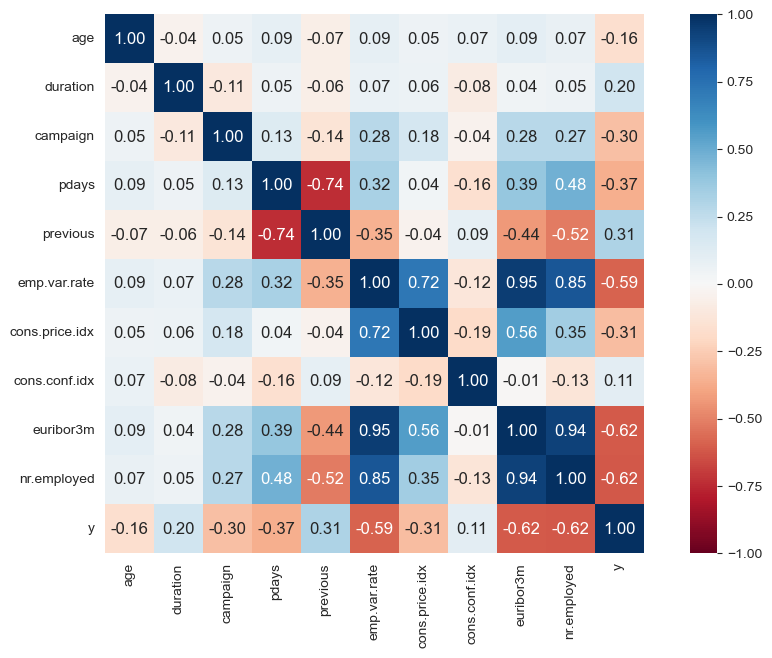

In [17]:
plt.figure(figsize=(12,7))
sns.heatmap(df_num_scl.corr(method='pearson',numeric_only=True),square=True,annot=True,fmt='.2f',cmap='RdBu',vmin=-1,vmax=1,annot_kws={'size':12});

Spearman Correlation (Monotonic Relationships)

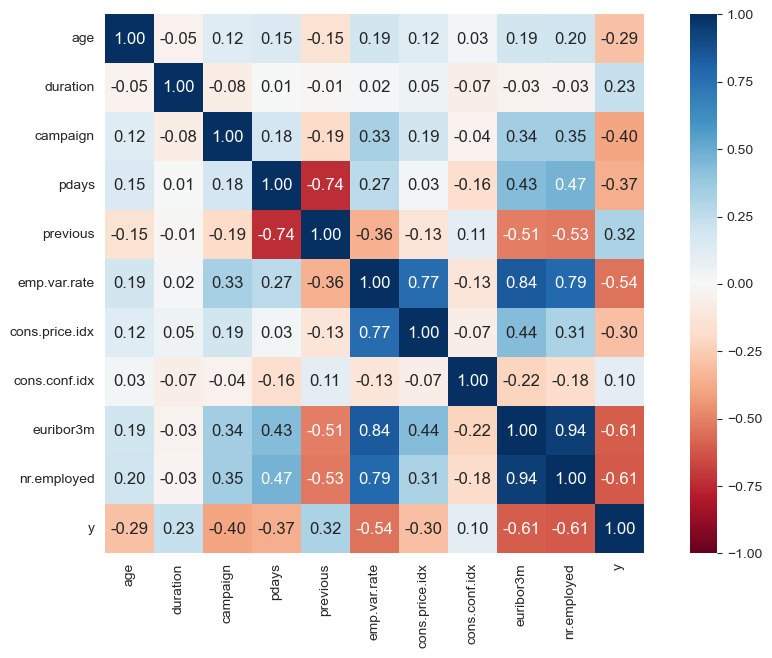

In [18]:
plt.figure(figsize=(12,7))
sns.heatmap(df_num_scl.corr(method='spearman',numeric_only=True),square=True,annot=True,fmt='.2f',cmap='RdBu',vmin=-1,vmax=1,annot_kws={'size':12});

Point-Biserial Correlation

In [19]:
from scipy.stats import pointbiserialr

corr_pbc = []

for col in df_num_scl.columns:
    corr = np.round(pointbiserialr(df_num_scl[col],df_num_scl['y']).correlation,2)
    pvalue = np.round(pointbiserialr(df_num_scl[col],df_num_scl['y']).pvalue,2)
    corr_pbc.append((col,corr,pvalue))

df_corr_pbc = pd.DataFrame(corr_pbc,columns=['Feature','Correlation','pvalue'])
df_corr_pbc.set_index('Feature',inplace=True)
df_corr_pbc.sort_values(by='Correlation',ascending=False)

,Correlation,pvalue
Feature,,
y,1.00,0.0
previous,0.31,0.0
duration,0.20,0.0
cons.conf.idx,0.11,0.0
age,-0.16,0.0
campaign,-0.30,0.0
cons.price.idx,-0.31,0.0
pdays,-0.37,0.0
emp.var.rate,-0.59,0.0


### Feature Selection

In [20]:
X_num = df_num_scl.drop('y',axis=1)
X_cat = df_cat_enc.drop('y',axis=1)
X_int = df_int.drop('y',axis=1)
y = df_int['y'].values.reshape(-1,1)
print(X_num.shape)
print(X_cat.shape)
print(X_int.shape)
print(y.shape)

(56160, 10)
(56160, 10)
(56160, 20)
(56160, 1)


#### Filter Methods

Information Gain

In [21]:
from sklearn.feature_selection import mutual_info_classif

info_gain = mutual_info_classif(X_int,y,n_neighbors=3,random_state=42)
importances = pd.Series(info_gain,index=X_int.columns).sort_values(ascending=False)
importances

euribor3m         0.311526
cons.conf.idx     0.266740
cons.price.idx    0.266147
nr.employed       0.245548
emp.var.rate      0.227479
duration          0.175812
age               0.115140
month             0.097189
campaign          0.091915
pdays             0.089263
job               0.085385
poutcome          0.083529
contact           0.080171
previous          0.056203
education         0.036784
loan              0.034279
marital           0.007066
housing           0.004402
day_of_week       0.000371
default           0.000000
dtype: float64

Variance Threshold

In [22]:
from sklearn.feature_selection import VarianceThreshold

v_threshold = VarianceThreshold(threshold=0)
v_threshold.fit(X_int)
variances = pd.Series(v_threshold.variances_,index=X_int.columns).sort_values(ascending=False)
variances

job               10.000000
month              6.761985
education          4.510024
day_of_week        1.909780
marital            0.330692
poutcome           0.252727
housing            0.249692
euribor3m          0.181923
contact            0.176427
emp.var.rate       0.131826
pdays              0.121842
nr.employed        0.113535
loan               0.076166
cons.price.idx     0.065236
cons.conf.idx      0.056060
duration           0.045711
age                0.022447
previous           0.010066
campaign           0.001605
default            0.000036
dtype: float64

ANOVA

In [23]:
from sklearn.feature_selection import SelectKBest,f_classif

kbest = SelectKBest(f_classif,k=5)
kbest.fit_transform(X_num,y)
mask = kbest.get_support()
scores = pd.DataFrame({'Score':kbest.scores_.tolist(),'pvalue':kbest.pvalues_.tolist()},index=X_num.columns)
scores = scores.sort_values(by='Score',ascending=False)
print(scores)
print('Top 5 Selected Features: ',X_num.columns[mask].to_list())

                       Score         pvalue
nr.employed     35628.151290   0.000000e+00
euribor3m       34239.849651   0.000000e+00
emp.var.rate    30384.032176   0.000000e+00
pdays            8689.383142   0.000000e+00
previous         5970.485071   0.000000e+00
cons.price.idx   5761.613834   0.000000e+00
campaign         5530.020439   0.000000e+00
duration         2287.494228   0.000000e+00
age              1564.966938   0.000000e+00
cons.conf.idx     662.148096  3.554497e-145
Top 5 Selected Features:  ['pdays', 'previous', 'emp.var.rate', 'euribor3m', 'nr.employed']


Chi-squared Test

In [24]:
from sklearn.feature_selection import SelectKBest,chi2

chi2_test = SelectKBest(chi2,k=5)
chi2_test.fit_transform(X_cat,y)
mask = chi2_test.get_support()
scores = pd.DataFrame({'Score':chi2_test.scores_.tolist(),'pvalue':chi2_test.pvalues_.tolist()},index=X_cat.columns)
scores = scores.sort_values(by='Score',ascending=False)
print(scores)
print('Top 5 Selected Features: ',X_cat.columns[mask].to_list())

                   Score         pvalue
contact      6297.970343   0.000000e+00
job          3196.392658   0.000000e+00
loan         3080.746195   0.000000e+00
education    1296.562278  6.313754e-284
poutcome      557.714243  2.641495e-123
day_of_week   219.219932   1.338251e-49
marital        69.310374   8.412595e-17
month          34.239860   4.872075e-09
housing        28.054671   1.179361e-07
default         2.000000   1.572992e-01
Top 5 Selected Features:  ['job', 'education', 'loan', 'contact', 'poutcome']


### Wrapper Methods

In [25]:
from sklearn.feature_selection import SequentialFeatureSelector,RFE
from sklearn.ensemble import RandomForestClassifier

Forward-Sequential Feature Selection

In [26]:
sfs_for = SequentialFeatureSelector(RandomForestClassifier(random_state=42,n_jobs=-1),direction='forward',n_features_to_select=5,n_jobs=-1)
sfs_for.fit_transform(X_int,y)
mask = sfs_for.get_support()
sfs_for_features = X_int.columns[mask].to_list()
sfs_for_features

['poutcome', 'age', 'duration', 'emp.var.rate', 'euribor3m']

Backward-Sequential Feature Selection

In [27]:
sfs_back = SequentialFeatureSelector(RandomForestClassifier(random_state=42,n_jobs=-1),direction='backward',n_features_to_select=5,n_jobs=-1)
sfs_back.fit_transform(X_int,y)
mask = sfs_back.get_support()
sfs_back_features = X_int.columns[mask].to_list()
sfs_back_features

['poutcome', 'age', 'duration', 'cons.price.idx', 'euribor3m']

Recursive Feature Elimination

In [28]:
rfe = RFE(RandomForestClassifier(random_state=42,n_jobs=-1),n_features_to_select=5)
rfe.fit_transform(X_int,y)
mask = rfe.get_support()
rfe_features = X_int.columns[mask].to_list()
rfe_features

['age', 'duration', 'emp.var.rate', 'euribor3m', 'nr.employed']

### Embedded Methods

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Logistic Regression Coefficients

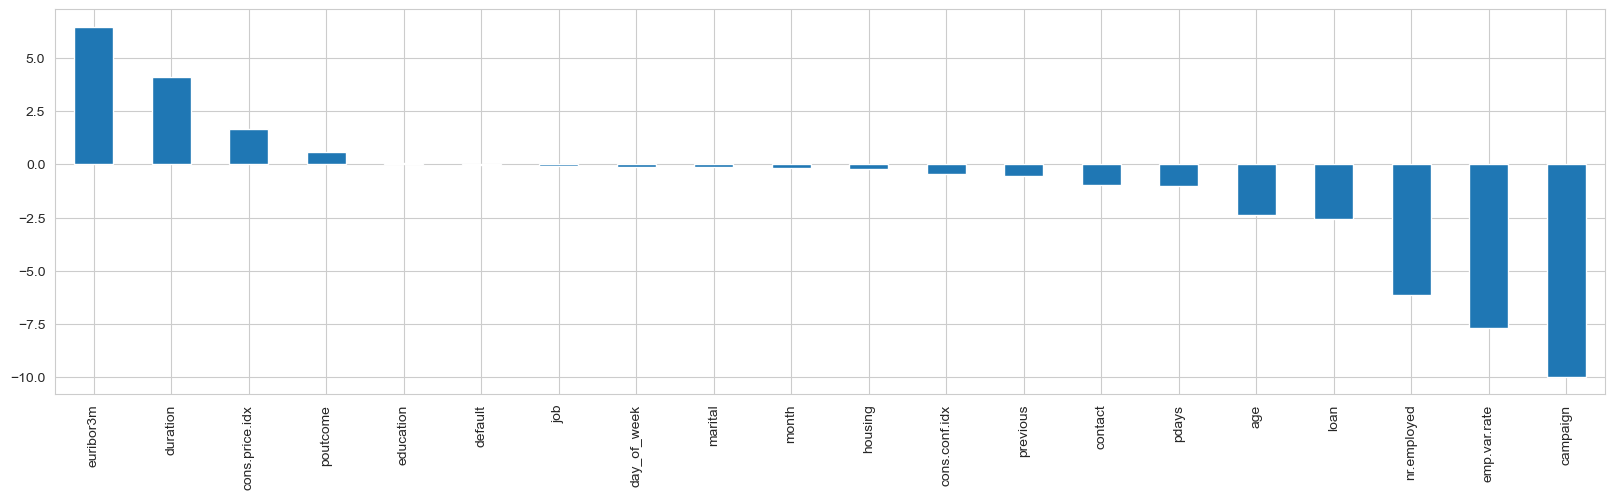

In [30]:
lr = LogisticRegression(C=1e5,random_state=42,n_jobs=-1)
lr.fit(X_int,y)
lr_coef = pd.Series(lr.coef_[0],index=X_int.columns)
lr_coef.sort_values(ascending=False).plot(kind='bar',figsize=(20,5));

Random Forest Feature Importances

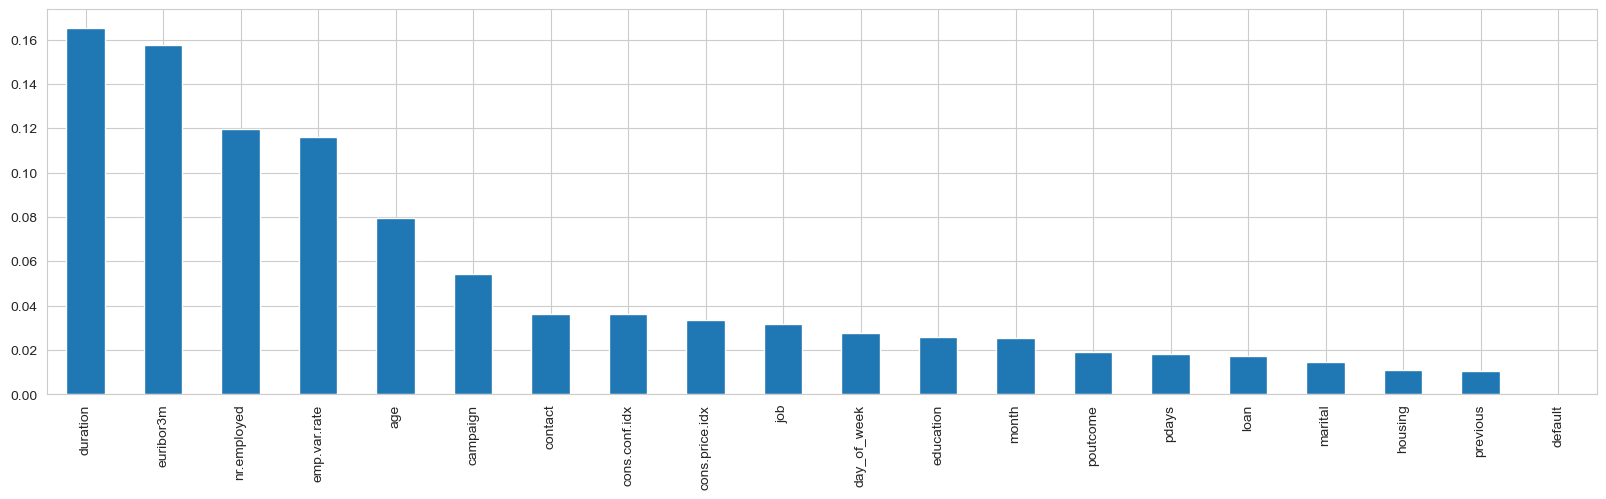

In [31]:
rfc = RandomForestClassifier(random_state=42,n_jobs=-1)
rfc.fit(X_int,y)
rf_FI = pd.Series(rfc.feature_importances_,index=X_int.columns)
rf_FI.sort_values(ascending=False).plot(kind='bar',figsize=(20,5));

XGBoost Feature Importances

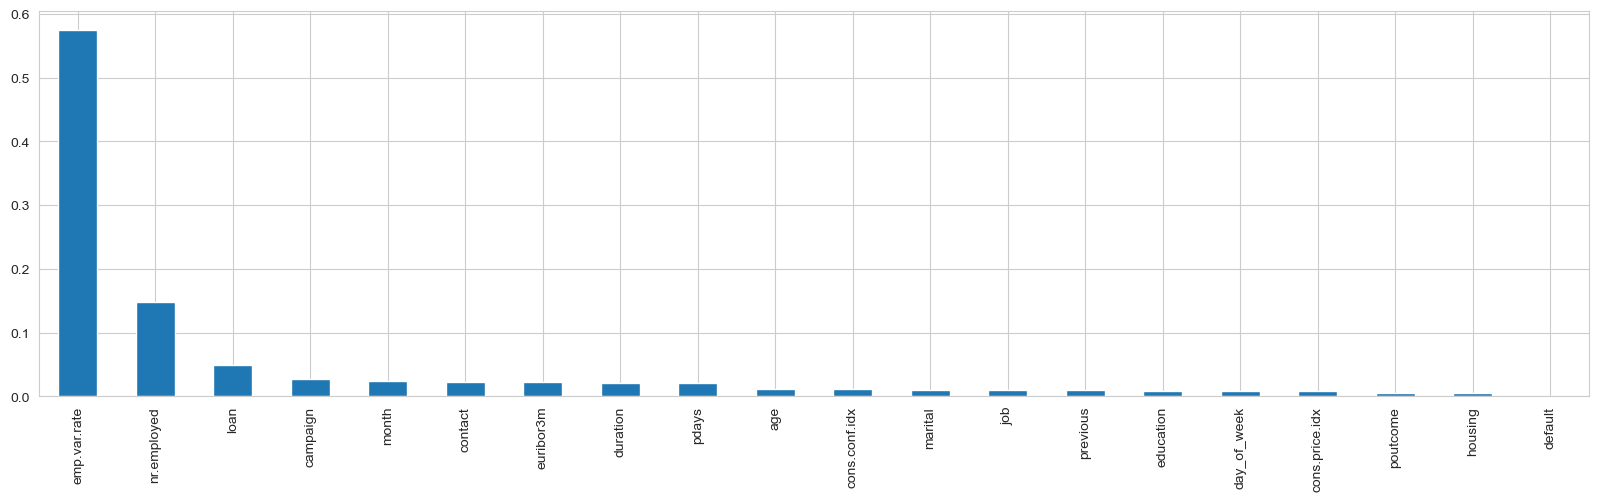

In [32]:
xgbc = XGBClassifier(random_state=42,n_jobs=-1)
xgbc.fit(X_int,y)
xgbc_FI = pd.Series(xgbc.feature_importances_,index=X_int.columns)
xgbc_FI.sort_values(ascending=False).plot(kind='bar',figsize=(20,5));

Linear Discrimant Analysis

In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

<Axes: >

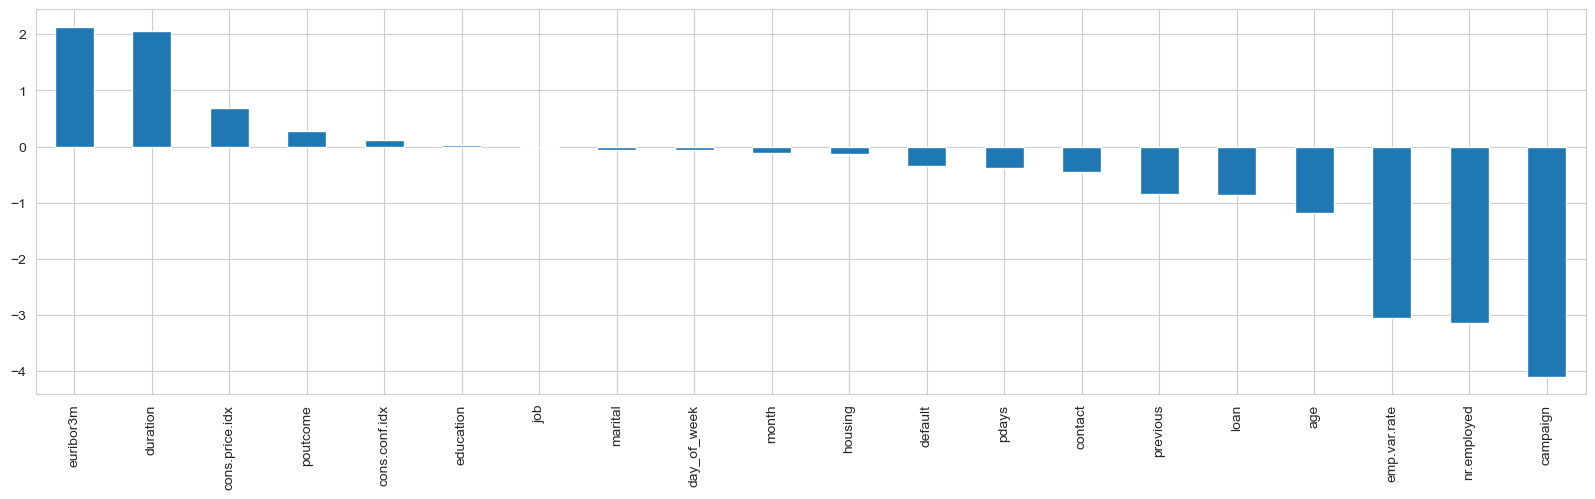

In [34]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_int,y)
lda_scalings = pd.Series(lda.scalings_.ravel(),index=X_int.columns)
lda_scalings.sort_values(ascending=False).plot(kind='bar',figsize=(20,5))

### Statistical Regression Analysis - Logistic Regression

In [35]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [36]:
# X = sm.add_constant(X_int)
glm_model_full = sm.GLM(y,X_int.assign(const=1),family=sm.families.Binomial()).fit()
results_glm_full = glm_model_full.summary()
print(results_glm_full)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                56160
Model:                            GLM   Df Residuals:                    56139
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18718.
Date:                Sat, 31 Aug 2024   Deviance:                       37435.
Time:                        15:17:10   Pearson chi2:                 9.27e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.5131
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
job               -0.0579      0.004    -15.

In [37]:
# X = sm.add_constant(X_int)
logit_model_full = sm.Logit(y,X_int.assign(const=1)).fit(method='bfgs',maxiter=1000)
results_logit_full = logit_model_full.summary()
print(results_logit_full)

Optimization terminated successfully.
         Current function value: 0.333292
         Iterations: 170
         Function evaluations: 171
         Gradient evaluations: 171
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                56160
Model:                          Logit   Df Residuals:                    56139
Method:                           MLE   Df Model:                           20
Date:                Sat, 31 Aug 2024   Pseudo R-squ.:                  0.5192
Time:                        15:17:11   Log-Likelihood:                -18718.
converged:                       True   LL-Null:                       -38927.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
job               -0.0579  

Variance Inflation Factor

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [39]:
selected_features = [
                     'duration',
                     'nr.employed',
                     'euribor3m',
                    #  'emp.var.rate',
                     'poutcome',
                    #  'pdays',
                    #  'cons.price.idx',
                    #  'cons.conf.idx',
                    #  'month',
                     'campaign',
                     'age'
                     ]

In [40]:
VIF = pd.DataFrame()
VIF['Features'] = selected_features
VIF['VIF'] = [variance_inflation_factor(X_int[selected_features].values,i) for i in range(X_int[selected_features].shape[1])]
VIF.sort_values(by='VIF',ascending=False)

,Features,VIF
1,nr.employed,22.017207
2,euribor3m,13.624610
3,poutcome,3.307054
5,age,3.306241
0,duration,3.136567
4,campaign,1.316418


In [41]:
# X = sm.add_constant(X_int)
glm_model_sel = sm.GLM(y,X_int[selected_features].assign(const=1),family=sm.families.Binomial()).fit()
results_glm_sel = glm_model_sel.summary()
print(results_glm_sel)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                56160
Model:                            GLM   Df Residuals:                    56153
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -21339.
Date:                Sat, 31 Aug 2024   Deviance:                       42677.
Time:                        15:17:11   Pearson chi2:                 7.60e+04
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4655
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
duration        3.7605      0.061     61.968      

In [42]:
# X = sm.add_constant(X_int)
logit_model_sel = sm.Logit(y,X_int[selected_features].assign(const=1)).fit()
results_logit_sel = logit_model_sel.summary()
print(results_logit_sel)

Optimization terminated successfully.
         Current function value: 0.379963
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                56160
Model:                          Logit   Df Residuals:                    56153
Method:                           MLE   Df Model:                            6
Date:                Sat, 31 Aug 2024   Pseudo R-squ.:                  0.4518
Time:                        15:17:11   Log-Likelihood:                -21339.
converged:                       True   LL-Null:                       -38927.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
duration        3.7605      0.061     61.968      0.000       3.642       3.879
nr.employed    -3.9142    